Creamos una aproximacion cuadratica con una API que resuelve el problema por SIMPLEX, que es lo que se usan muchas veces los bancos para obtener los pesos. <br>
Tambien dubujaremos la frontera eficiente con esta

In [30]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [31]:
p1 = 0.3
m1 = 0.1180850933
m2 = 0.1619481497
m3 = 0.0771816605
v1 = 0.03492332644
v2 = 0.02776645397
v3 = 0.03505910984
cv12 = 0.001666029016
cv13 = 0.0005078163229
cv23 = 0.0005112105901

cov = np.array([
    [v1,    cv12, cv13],
    [cv12,  v2,   cv23],
    [cv13,  cv23, v3  ]
])
#Datos iguales que los otros notebook y archivos .py

In [32]:
medias = np.array([m1, m2, m3])
E_valor = 0.0771816605
res = [] #Matriz acumuladora de resultados

In [ ]:
while E_valor <= 0.1619481497:
    p = cp.Variable(3) # Vector solucion, los 3 pesos
    objetivo = cp.Minimize(cp.quad_form(p, cov)) # Intentamos minimizar la covarianza
    # Reestricciones
    restricciones = [
        cp.sum(p) == 1, # Los pesos suman 1
        medias @ p == E_valor, # El retorno tiene que ser exactamente nuestra E fijada en el wile
        p >= 0 # Los pesos tienen que ser postiivos
    ]
    # Establecemos el problema y resolvemos, el algoritmo no es muy importante, es simplemente optimizacion cuadratica
    prob = cp.Problem(objetivo, restricciones) 
    prob.solve(solver=cp.CLARABEL) # Resuelve por simplex
    # Si los valores son buenos, guardamos con las matrices multiplicadas
    if prob.status == "optimal":
        pesos = p.value
        V_opt = float(pesos @ cov @ pesos)
        # Guardamos pesos
        res.append([E_valor, V_opt, pesos[0], pesos[1], pesos[2]])
    
    E_valor += 0.002 # Avanzamos un paso

In [ ]:
# Separamos para hacer el plot
E_vals_r = np.array([row[0] for row in res])
V_vals_r = np.array([row[1] for row in res])

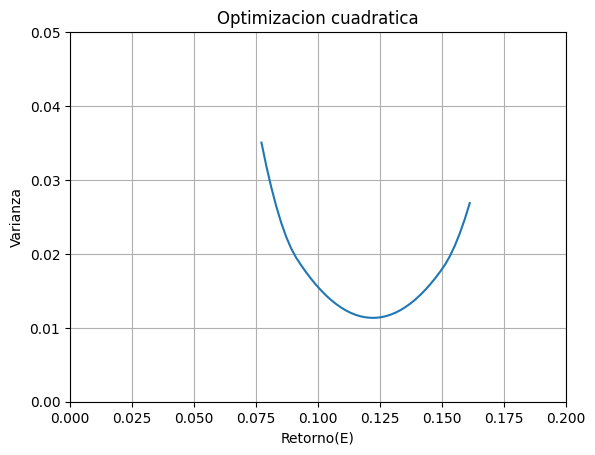

In [43]:
plt.figure()
plt.plot(E_vals_r, V_vals_r)
plt.xlabel("Retorno(E)")
plt.ylabel("Varianza")
plt.title("Optimizacion cuadratica")
plt.xlim(0, 0.2)
plt.ylim(0, 0.05)
plt.grid(True)
plt.savefig("Optimizacion cuadratica.png", dpi=300, bbox_inches="tight")
plt.show()